In [33]:
import pandas as pd
import cbbpy.mens_scraper as s
import numpy as np

In [19]:
df = pd.read_csv('../data/archived_results.csv')
df = df[pd.notna(df['game_id'])]
df['game_id'] = df['game_id'].astype('Int64')

In [20]:
game_ids = df['game_id']

In [ ]:
games = []

for i, game_id in enumerate(game_ids, start=1):
    try:
        game, _, _ = s.get_game(game_id, box = False, pbp = False)
        games.append(game)
        print(f'Successfully recieved {game_id}! - {i} / {len(game_ids)}')
    except Exception as e:
        print(f"Failed to retrieve {game_id}: {e}")

schedule = pd.concat(games, ignore_index=True)

In [23]:
schedule['game_id'] = schedule['game_id'].astype('Int64')
df = df.merge(schedule[['game_id', 'home_point_spread']], on='game_id')

In [29]:
df = df.rename(columns={'home_point_spread': 'closing_spread'})

In [31]:
df['closing_spread'] = df['closing_spread'].astype('float64')
clv = df['home_team_spread'] - df['closing_spread']

In [87]:
edge = df['home_team_spread'] - df['closing_spread']

# Scenario 1: Model favors home MORE than market (e.g., model -6.5, closing -5.5)
# Bet HOME, win if home covers closing spread
home_bet = edge < 0
home_win = df['home_dff'] + df['closing_spread'] > 0

# Scenario 2: Model favors home LESS than market (e.g., model -4.5, closing -6.5)
# Bet AWAY, win if home does NOT cover closing spread
away_bet = edge > 0
away_win = df['home_dff'] + df['closing_spread'] < 0

df['bet'] = np.where(home_bet, 'home',
            np.where(away_bet, 'away', 'no_bet'))

df['bet_result'] = np.where(
    home_bet & home_win, 'win',        # bet home, home covered
    np.where(
    home_bet & ~home_win, 'loss',      # bet home, home failed to cover
    np.where(
    away_bet & away_win, 'win',        # bet away, away covered
    np.where(
    away_bet & ~away_win, 'loss',      # bet away, away failed to cover
    np.where(
    (df['home_dff'] + df['closing_spread']) == 0, 'push',  # exact cover
    'no_bet')))))

df['profit'] = np.where(df['bet_result'] == 'win',   100,
               np.where(df['bet_result'] == 'loss', -110,
               np.where(df['bet_result'] == 'push',    0, 0)))

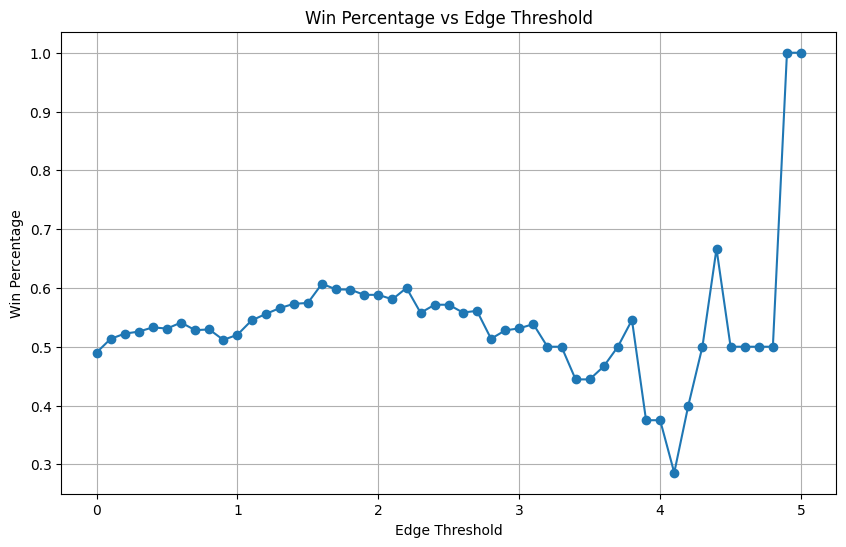

In [97]:
import matplotlib.pyplot as plt

thresholds = [i * 0.1 for i in range(51)]  # 0 to 5 in 0.1 steps
win_percentages = []

for edge in thresholds:
    edge_bets = df[abs(df['edge']) >= edge]
    if len(edge_bets) > 0:
        win_count = sum(edge_bets['bet_result'] == 'win')
        win_percentage = win_count / len(edge_bets)
    else:
        win_percentage = 0
    win_percentages.append(win_percentage)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, win_percentages, marker='o')
plt.title('Win Percentage vs Edge Threshold')
plt.xlabel('Edge Threshold')
plt.ylabel('Win Percentage')
plt.grid(True)
plt.show()

Win rate:        59.0%
Break-even:      52.38%
EV per bet:      $13.90
Expected P&L:    $27,896
ROI:             12.7%
% sims profit:   100%
Best sim:        $45,440
Worst sim:       $7,220


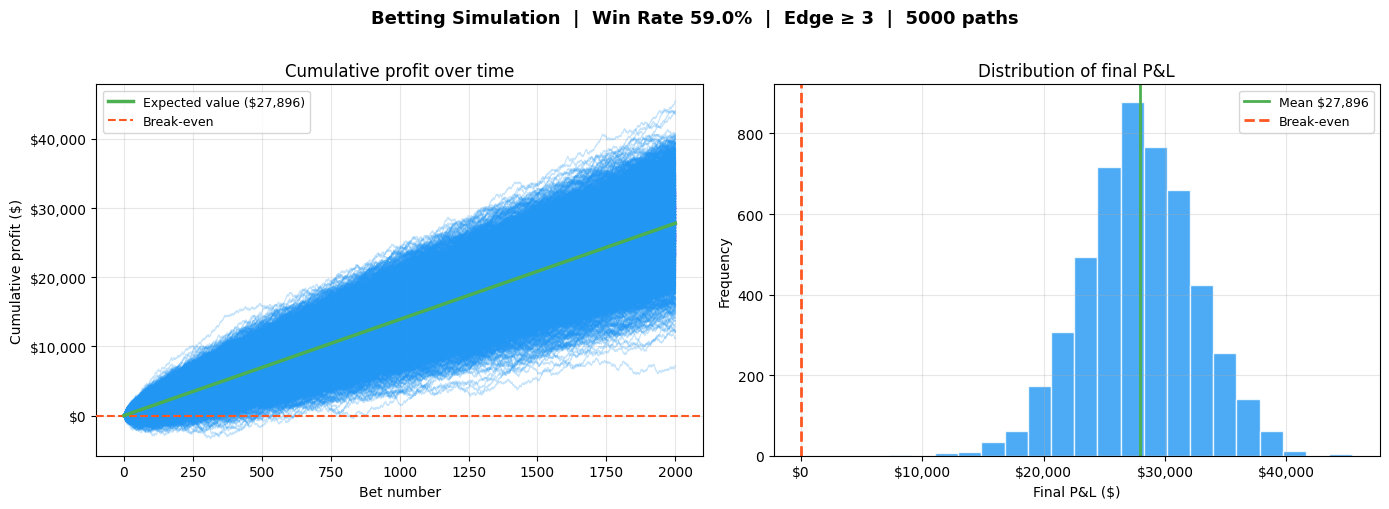

Saved → betting_simulation.png


In [102]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── CONFIG ──────────────────────────────────────────────────────────────────
WIN_RATE    = 0.59   # e.g. 0.531 = 53.1%
NUM_BETS    = 2000
BET_SIZE    = 110     # amount risked per bet
PAYOUT      = 100     # profit on a win (standard -110 juice)
NUM_SIMS    = 5000      # number of simulation paths
EDGE_THRESHOLD = 3    # for title label only
# ────────────────────────────────────────────────────────────────────────────

def simulate(win_rate, num_bets, bet_size, payout, num_sims, seed=42):
    rng = np.random.default_rng(seed)
    outcomes = rng.random((num_sims, num_bets))
    profits  = np.where(outcomes < win_rate, payout, -bet_size)
    cum      = np.cumsum(profits, axis=1)
    cum      = np.hstack([np.zeros((num_sims, 1)), cum])
    return cum

cum_paths = simulate(WIN_RATE, NUM_BETS, BET_SIZE, PAYOUT, NUM_SIMS)

# Expected value line
ev_per_bet = WIN_RATE * PAYOUT - (1 - WIN_RATE) * BET_SIZE
ev_line    = np.arange(NUM_BETS + 1) * ev_per_bet

# ── STATS ────────────────────────────────────────────────────────────────────
final_pnls  = cum_paths[:, -1]
mean_final  = final_pnls.mean()
pct_profit  = (final_pnls > 0).mean() * 100
roi         = mean_final / (NUM_BETS * BET_SIZE) * 100

print(f"Win rate:        {WIN_RATE:.1%}")
print(f"Break-even:      52.38%")
print(f"EV per bet:      ${ev_per_bet:.2f}")
print(f"Expected P&L:    ${mean_final:,.0f}")
print(f"ROI:             {roi:.1f}%")
print(f"% sims profit:   {pct_profit:.0f}%")
print(f"Best sim:        ${final_pnls.max():,.0f}")
print(f"Worst sim:       ${final_pnls.min():,.0f}")

# ── PLOT ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Betting Simulation  |  Win Rate {WIN_RATE:.1%}  |  Edge ≥ {EDGE_THRESHOLD}  |  {NUM_SIMS} paths",
    fontsize=13, fontweight="bold", y=1.01
)

# -- Left: cumulative profit paths --
ax = axes[0]
for path in cum_paths:
    color = "#2196F3" if path[-1] >= 0 else "#F44336"
    ax.plot(path, color=color, alpha=0.25, linewidth=0.9)

ax.plot(ev_line, color="#4CAF50", linewidth=2.5, label=f"Expected value (${mean_final:,.0f})", zorder=5)
ax.axhline(0, color="#FF5722", linewidth=1.5, linestyle="--", label="Break-even", zorder=4)

ax.set_xlabel("Bet number")
ax.set_ylabel("Cumulative profit ($)")
ax.set_title("Cumulative profit over time")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# -- Right: distribution of final P&L --
ax2 = axes[1]
ax2.hist(final_pnls, bins=20, color="#2196F3", edgecolor="white", alpha=0.8)
ax2.axvline(mean_final, color="#4CAF50", linewidth=2, linestyle="-",  label=f"Mean ${mean_final:,.0f}")
ax2.axvline(0,          color="#FF5722", linewidth=2, linestyle="--", label="Break-even")
ax2.set_xlabel("Final P&L ($)")
ax2.set_ylabel("Frequency")
ax2.set_title("Distribution of final P&L")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Saved → betting_simulation.png")